COMPARE ZERO-COMMENT RATES: bat_score>0 vs. MATCHED bat_score=0
bat_score>0 group: 12,237 posts
bat_score=0 comparison group: 12,237 posts
Scanning r/ciso...
  Matched 277 top-level comments
Scanning r/cybersecurity...
  Matched 43,871 top-level comments
Scanning r/SecurityCareerAdvice...
  Matched 5,669 top-level comments
Scanning r/sysadmin...
  Matched 42,583 top-level comments
Scanning r/asknetsec...
  Matched 2,743 top-level comments

ZERO-COMMENT RATE COMPARISON
                       n_posts  n_zero_comments  mean_comment_count  \
group                                                                 
bat_score=0 (matched)    12237             8852            2.529868   
bat_score>0              12237             8716            5.245158   

                       median_comment_count  pct_zero  
group                                                  
bat_score=0 (matched)                   0.0     72.34  
bat_score>0                             0.0     71.23  

Two-proportion z-

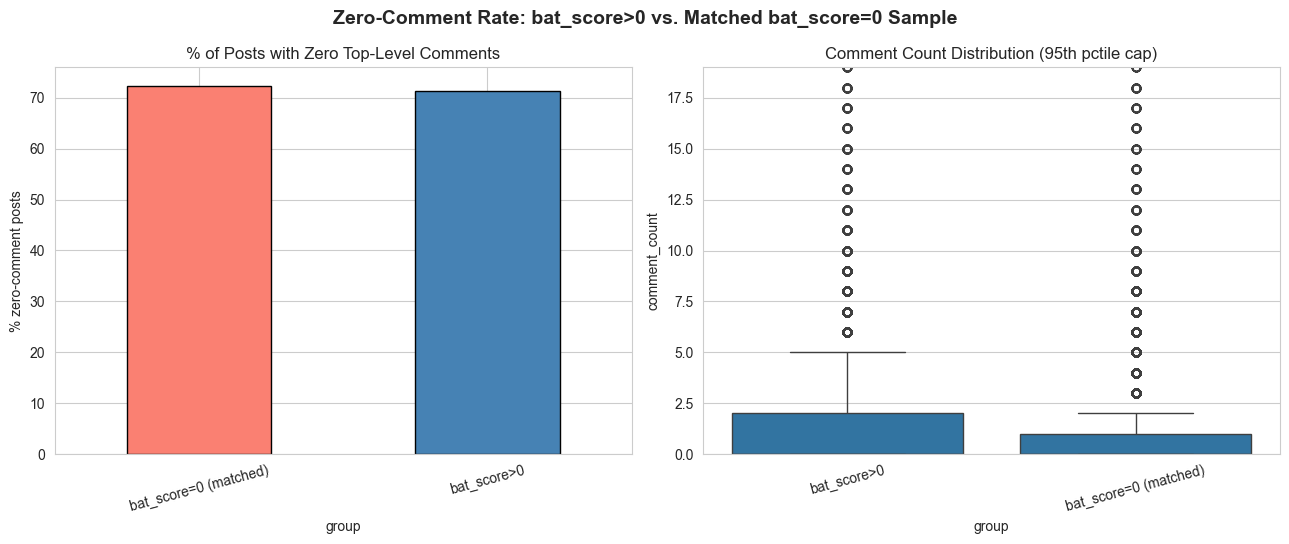

In [1]:
"""
COMPARE ZERO-COMMENT RATES: bat_score>0 vs. MATCHED bat_score=0 SAMPLE
==========================================================================
Question: is the ~72% zero-comment rate among bat_score>0 posts elevated
relative to baseline subreddit behavior, or is it just how these
communities behave regardless of burnout content?

Scans raw .jsonl comment files ONCE, checking each comment's link_id
against BOTH target sets simultaneously (more efficient than two
separate passes over the same files).

Reads:
    bat_score_pos.csv               (bat_score>0 group)
    bat0_comparison_sample.csv       (matched bat_score=0 group)
    r_<subreddit>_comments.jsonl     (raw, all 5 subreddits)

Writes:
    zero_comment_rate_comparison.csv
    zero_comment_rate_comparison.png
"""

import json
import os
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns

# ── CONFIG ───────────────────────────────────────────────────────────────────
DATA_DIR = '/Users/nadia/Desktop/redditRun_june/comment_data/'
BAT_POS_FILE = DATA_DIR + 'bat_score_pos.csv'
BAT0_SAMPLE_FILE = DATA_DIR + 'bat0_comparison_sample.csv'
OUTPUT_DIR = DATA_DIR

SUBREDDITS = ['ciso', 'cybersecurity', 'SecurityCareerAdvice', 'sysadmin', 'asknetsec']
RAW_COMMENT_EXT = '.jsonl'

sns.set_style("whitegrid")


def load_target_sets():
    pos = pd.read_csv(BAT_POS_FILE, usecols=['post_id', 'bat_score'])
    pos['post_id'] = pos['post_id'].astype(str)
    pos['group'] = 'bat_score>0'

    zero = pd.read_csv(BAT0_SAMPLE_FILE, usecols=['post_id', 'bat_score'])
    zero['post_id'] = zero['post_id'].astype(str)
    zero['group'] = 'bat_score=0 (matched)'

    print(f"bat_score>0 group: {len(pos):,} posts")
    print(f"bat_score=0 comparison group: {len(zero):,} posts")

    combined = pd.concat([pos[['post_id', 'group']], zero[['post_id', 'group']]], ignore_index=True)
    all_ids = set(combined['post_id'])
    return combined, all_ids


def scan_comment_counts(all_ids):
    counts = {pid: 0 for pid in all_ids}

    for sub in SUBREDDITS:
        raw_path = DATA_DIR + f'r_{sub}_comments{RAW_COMMENT_EXT}'
        if not os.path.exists(raw_path):
            print(f"  ⚠ Skipping r/{sub}: file not found")
            continue

        print(f"Scanning r/{sub}...")
        matched = 0
        with open(raw_path, 'r', encoding='utf-8', errors='replace') as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                try:
                    rec = json.loads(line)
                except json.JSONDecodeError:
                    continue

                parent_id = str(rec.get('parent_id', ''))
                if not parent_id.startswith('t3_'):
                    continue  # only top-level, matching the original pipeline

                link_id = str(rec.get('link_id', ''))
                post_id = link_id.replace('t3_', '', 1)
                if post_id not in all_ids:
                    continue

                counts[post_id] += 1
                matched += 1

        print(f"  Matched {matched:,} top-level comments")

    return counts


def compare_rates(combined, counts):
    combined['comment_count'] = combined['post_id'].map(counts).fillna(0).astype(int)
    combined['has_zero_comments'] = (combined['comment_count'] == 0).astype(int)

    print("\n" + "=" * 60)
    print("ZERO-COMMENT RATE COMPARISON")
    print("=" * 60)

    summary = combined.groupby('group').agg(
        n_posts=('post_id', 'count'),
        n_zero_comments=('has_zero_comments', 'sum'),
        mean_comment_count=('comment_count', 'mean'),
        median_comment_count=('comment_count', 'median'),
    )
    summary['pct_zero'] = (summary['n_zero_comments'] / summary['n_posts'] * 100).round(2)
    print(summary)

    # Two-proportion z-test
    counts_arr = summary['n_zero_comments'].values
    nobs_arr = summary['n_posts'].values
    z_stat, p_val = proportions_ztest(counts_arr, nobs_arr)
    print(f"\nTwo-proportion z-test: z={z_stat:.3f}, p={p_val:.4g}")

    # Chi-square test (equivalent, reported alongside for robustness)
    contingency = pd.crosstab(combined['group'], combined['has_zero_comments'])
    chi2, p_chi2, dof, expected = chi2_contingency(contingency)
    print(f"Chi-square test: chi2={chi2:.3f}, p={p_chi2:.4g}")

    diff = summary.loc['bat_score>0', 'pct_zero'] - summary.loc['bat_score=0 (matched)', 'pct_zero']
    print(f"\nDifference in zero-comment rate (bat_score>0 minus matched bat_score=0): "
          f"{diff:+.2f} percentage points")

    return combined, summary


def make_figure(combined, summary):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
    fig.suptitle('Zero-Comment Rate: bat_score>0 vs. Matched bat_score=0 Sample',
                  fontsize=14, fontweight='bold')

    summary['pct_zero'].plot(kind='bar', ax=axes[0], color=['salmon', 'steelblue'], edgecolor='black')
    axes[0].set_title('% of Posts with Zero Top-Level Comments')
    axes[0].set_ylabel('% zero-comment posts')
    axes[0].tick_params(axis='x', rotation=15)

    sns.boxplot(data=combined, x='group', y='comment_count', ax=axes[1])
    axes[1].set_ylim(0, combined['comment_count'].quantile(0.95))
    axes[1].set_title('Comment Count Distribution (95th pctile cap)')
    axes[1].tick_params(axis='x', rotation=15)

    plt.tight_layout()
    out_path = OUTPUT_DIR + 'zero_comment_rate_comparison.png'
    plt.savefig(out_path, dpi=200, bbox_inches='tight')
    print(f"\n✓ Figure saved: {out_path}")


if __name__ == '__main__':
    print("=" * 80)
    print("COMPARE ZERO-COMMENT RATES: bat_score>0 vs. MATCHED bat_score=0")
    print("=" * 80)

    combined, all_ids = load_target_sets()
    counts = scan_comment_counts(all_ids)
    combined, summary = compare_rates(combined, counts)
    make_figure(combined, summary)

    combined.to_csv(OUTPUT_DIR + 'zero_comment_rate_comparison.csv', index=False)
    print(f"\n✓ zero_comment_rate_comparison.csv saved  →  {len(combined):,} posts")